# CampusIQ — AI-Powered Student Analytics & Placement Prediction System

**Developed By:** Shibang Maity, Roshan Panda, Priyanshu Sekhar Bhuyan  
**Institution:** KIIT University  
**Dataset:** CampusIQ_Final_Dataset_Presentation.csv (600 students, 21 features)  
**Updated:** 2026

### Technologies Used
- Python | PostgreSQL | Pandas | NumPy
- Matplotlib | Seaborn
- Scikit-learn (Logistic Regression, Decision Tree, Random Forest, KNN, SVM)
- Groq (Llama 3.3) | ChromaDB (RAG)
- Streamlit (deployed separately) | Plotly

### Project Overview
This notebook covers the end-to-end placement prediction pipeline:
1. Data loading and inspection
2. Data cleaning (categorical normalization, CGPA validation)
3. Exploratory Data Analysis (EDA)
4. Feature engineering (Yes/No derived flags for internship, certification, placement — no data leakage from `Placement_Status`)
5. Correlation analysis
6. Model training — Logistic Regression, Decision Tree, Random Forest, KNN, SVM
7. Model evaluation (accuracy, confusion matrix, classification report)
8. Feature importance
9. Model export (pickle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("CampusIQ_Final_Dataset_Presentation.csv")

df.head()

,Student_Name,Gender,Stream,Branch,Semester,10th_%,10th_Board,10th_Passout_Year,12th_%,12th_Education,12th_Passout_Year,University_Admission_Year,CGPA,Attendance_%,Backlog,Top_Certification,Internship_Status,Projects_Count,Placement_Status
0,s1,Male,B.Tech,IT,1,79.07,CBSE,2024,84.44,CBSE - Science,2026.0,2026,8.68,90.0,No,Cisco CCNA,Not Yet,2,Not Placed
1,s2,Male,Diploma,Diploma Mechanical,1,74.22,State Board,2025,NaN,Diploma (Lateral Entry),NaN,2026,5.20,75.0,Yes,ETABS,Not Yet,3,Not Placed
2,s3,Male,BCA,Computer Applications,1,63.83,CBSE,2023,69.28,ISC - Arts,2025.0,2026,7.11,87.0,No,Cisco CCNA,Not Yet,2,Not Placed
3,s4,Female,M.Tech,Communication Systems,2,72.03,CBSE,2020,67.85,CBSE - Science,2022.0,2026,7.47,89.0,No,Python,Not Yet,1,Not Placed
4,s5,Male,Diploma,Diploma Electrical,6,85.00,CBSE,2024,NaN,Diploma (Lateral Entry),NaN,2024,8.57,90.0,Yes,No Certification,Ongoing - Wipro,2,Placed - Accenture


In [6]:
df.shape

(600, 19)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_Name               600 non-null    object 
 1   Gender                     600 non-null    object 
 2   Stream                     600 non-null    object 
 3   Branch                     600 non-null    object 
 4   Semester                   600 non-null    int64  
 5   10th_%                     600 non-null    float64
 6   10th_Board                 600 non-null    object 
 7   10th_Passout_Year          600 non-null    int64  
 8   12th_%                     587 non-null    float64
 9   12th_Education             600 non-null    object 
 10  12th_Passout_Year          587 non-null    float64
 11  University_Admission_Year  600 non-null    int64  
 12  CGPA                       600 non-null    float64
 13  Attendance_%               600 non-null    float64

In [8]:
df.isnull().sum()

Student_Name                  0
Gender                        0
Stream                        0
Branch                        0
Semester                      0
10th_%                        0
10th_Board                    0
10th_Passout_Year             0
12th_%                       13
12th_Education                0
12th_Passout_Year            13
University_Admission_Year     0
CGPA                          0
Attendance_%                  0
Backlog                       0
Top_Certification             0
Internship_Status             0
Projects_Count                0
Placement_Status              0
dtype: int64

In [9]:
df.describe()

,Semester,10th_%,10th_Passout_Year,12th_%,12th_Passout_Year,University_Admission_Year,CGPA,Attendance_%,Projects_Count
count,600.000000,600.000000,600.000000,587.000000,587.000000,600.000000,600.000000,600.000000,600.000000
mean,4.210000,80.702083,2021.725000,77.613935,2023.664395,2024.741667,7.867833,81.942500,2.193333
std,2.572988,10.774423,1.731388,10.479474,1.696657,1.172129,0.939351,10.388091,1.207637
min,1.000000,52.210000,2018.000000,53.840000,2020.000000,2023.000000,5.150000,41.000000,0.000000
25%,2.000000,73.537500,2020.000000,68.195000,2022.000000,2024.000000,7.220000,75.000000,1.000000
50%,4.000000,81.215000,2022.000000,78.100000,2024.000000,2025.000000,7.910000,83.000000,2.000000
75%,6.000000,89.425000,2023.000000,87.390000,2025.000000,2026.000000,8.582500,90.000000,3.000000
max,8.000000,97.970000,2026.000000,94.930000,2026.000000,2026.000000,10.000000,100.000000,5.000000


In [10]:
df["Placement_Status"].value_counts()

Placement_Status
Not Placed                      484
Placed - Accenture               17
Placed - IBM                     13
Placed - Adobe                    9
Placed - Cognizant                8
Placed - Infosys                  8
Placed - Deloitte                 8
Placed - TCS                      7
Placed - Microsoft                5
Placed - Tech Mahindra            5
Placed - Goldman Sachs            5
Placed - Capgemini                5
Placed - Wipro                    5
Placed - NTPC                     3
Placed - Amazon                   3
Placed - HCL                      3
Placed - Bosch                    3
Placed - BHEL                     2
Placed - Mahindra & Mahindra      2
Placed - Tata Motors              2
Placed - DRDO                     1
Placed - ONGC                     1
Placed - Google                   1
Name: count, dtype: int64

In [11]:
df["Placement_Result"] = df["Placement_Status"].apply(
    lambda x: "Placed" if x != "Not Placed" else "Not Placed"
)

In [12]:
df[["Placement_Status","Placement_Result"]].head(15)

,Placement_Status,Placement_Result
0,Not Placed,Not Placed
1,Not Placed,Not Placed
2,Not Placed,Not Placed
3,Not Placed,Not Placed
4,Placed - Accenture,Placed
5,Placed - NTPC,Placed
6,Not Placed,Not Placed
7,Not Placed,Not Placed
8,Not Placed,Not Placed
9,Not Placed,Not Placed


In [13]:
df["Placement_Result"].value_counts()

Placement_Result
Not Placed    484
Placed        116
Name: count, dtype: int64

In [14]:
def extract_company(status):

    if status == "Not Placed":
        return "Not Placed"

    return status.replace("Placed - ", "")

In [15]:
df["Company"] = df["Placement_Status"].apply(extract_company)

In [16]:
df[["Placement_Status","Company"]].head(20)

,Placement_Status,Company
0,Not Placed,Not Placed
1,Not Placed,Not Placed
2,Not Placed,Not Placed
3,Not Placed,Not Placed
4,Placed - Accenture,Accenture
5,Placed - NTPC,NTPC
6,Not Placed,Not Placed
7,Not Placed,Not Placed
8,Not Placed,Not Placed
9,Not Placed,Not Placed


In [17]:
df["Company"].value_counts()

Company
Not Placed             484
Accenture               17
IBM                     13
Adobe                    9
Cognizant                8
Infosys                  8
Deloitte                 8
TCS                      7
Microsoft                5
Tech Mahindra            5
Goldman Sachs            5
Capgemini                5
Wipro                    5
NTPC                     3
Amazon                   3
HCL                      3
Bosch                    3
BHEL                     2
Mahindra & Mahindra      2
Tata Motors              2
DRDO                     1
ONGC                     1
Google                   1
Name: count, dtype: int64

In [18]:
df.to_csv("CampusIQ_Cleaned.csv", index=False)

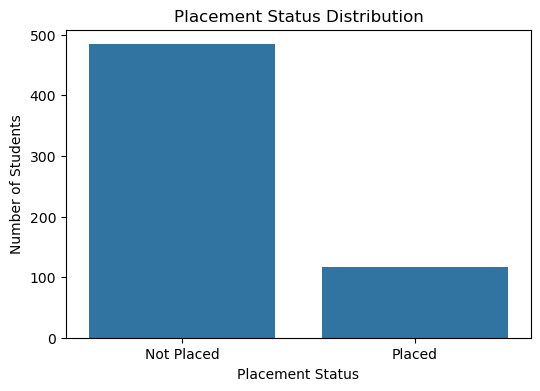

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Placement_Result"
)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

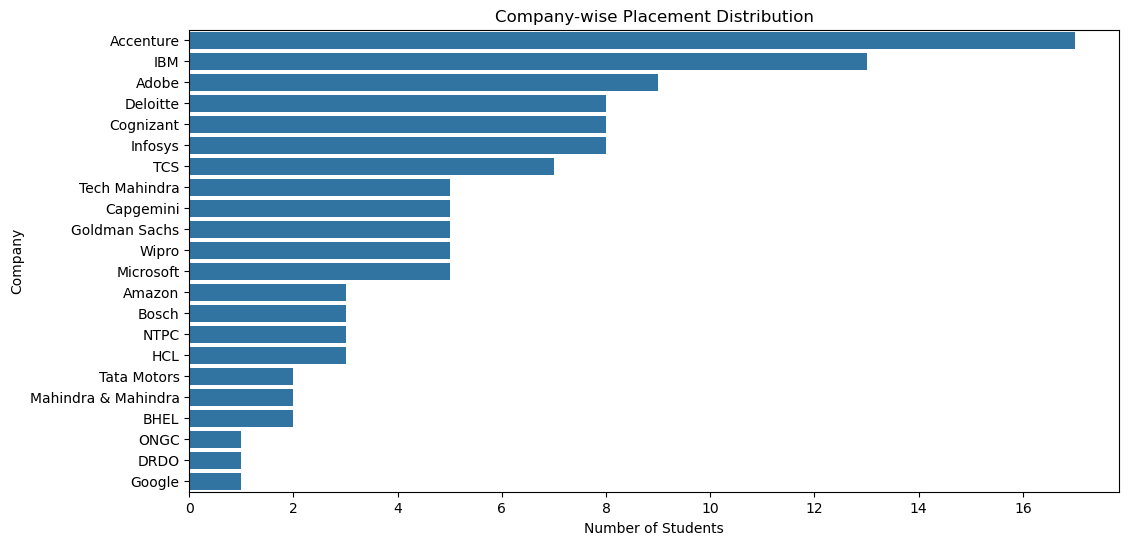

In [20]:
placed_df = df[df["Placement_Result"] == "Placed"]

plt.figure(figsize=(12, 6))

company_counts = placed_df["Company"].value_counts()

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title("Company-wise Placement Distribution")
plt.xlabel("Number of Students")
plt.ylabel("Company")
plt.show()

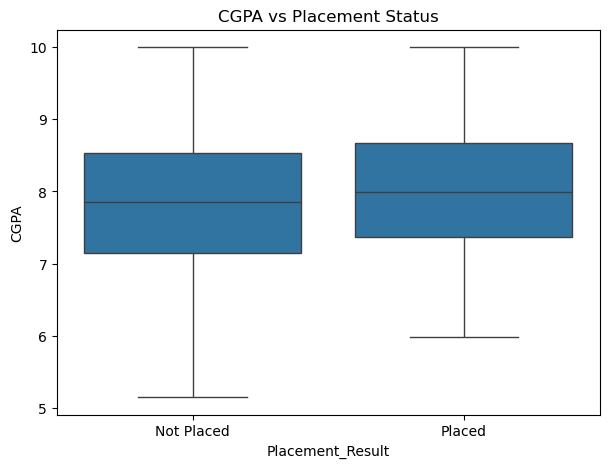

In [21]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Placement_Result",
    y="CGPA"
)

plt.title("CGPA vs Placement Status")
plt.show()

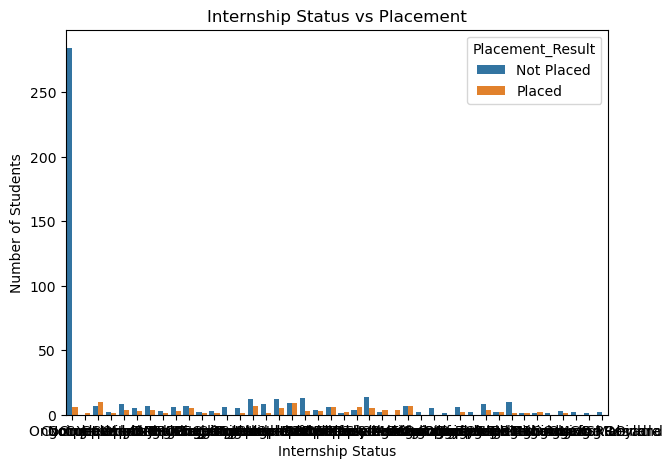

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Internship_Status",
    hue="Placement_Result"
)

plt.title("Internship Status vs Placement")
plt.xlabel("Internship Status")
plt.ylabel("Number of Students")
plt.show()

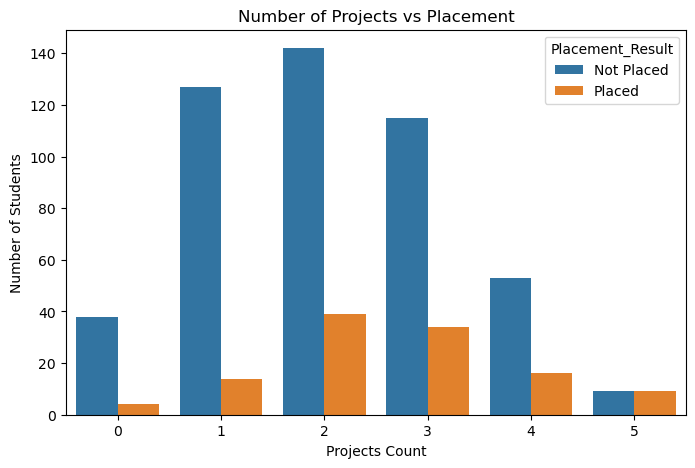

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Projects_Count",
    hue="Placement_Result"
)

plt.title("Number of Projects vs Placement")
plt.xlabel("Projects Count")
plt.ylabel("Number of Students")
plt.show()

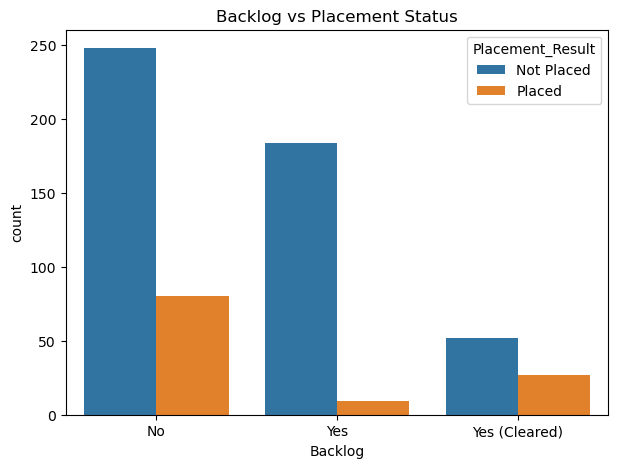

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Backlog",
    hue="Placement_Result"
)

plt.title("Backlog vs Placement Status")
plt.show()

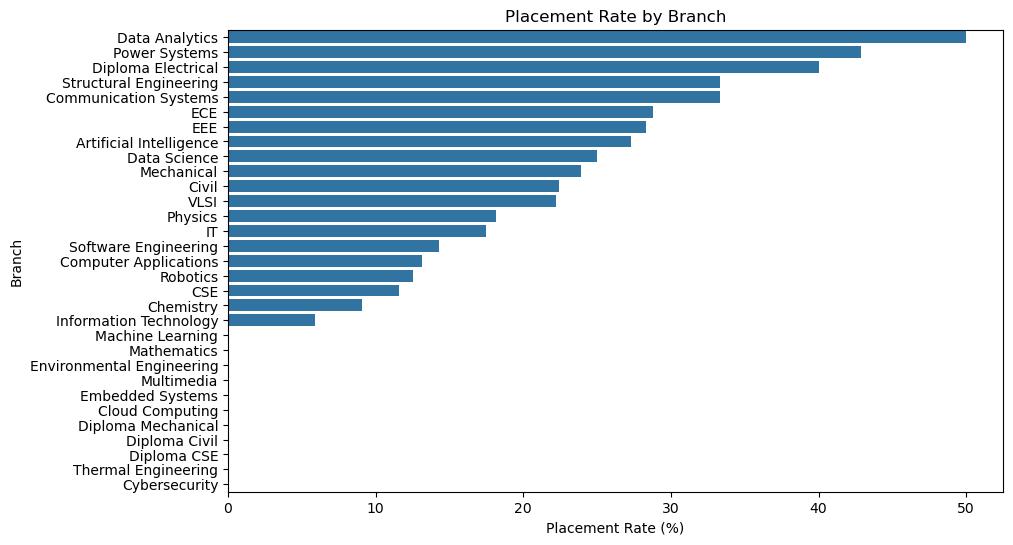

In [25]:
branch_placement_rate = (
    df.groupby("Branch")["Placement_Result"]
      .apply(lambda x: (x == "Placed").mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=branch_placement_rate.values,
    y=branch_placement_rate.index
)

plt.title("Placement Rate by Branch")
plt.xlabel("Placement Rate (%)")
plt.ylabel("Branch")
plt.show()

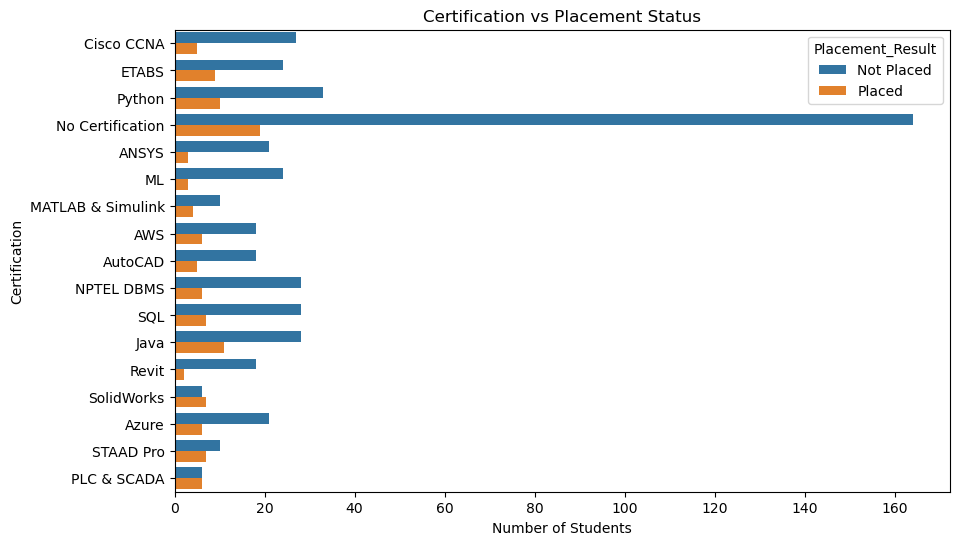

In [26]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Top_Certification",
    hue="Placement_Result"
)

plt.title("Certification vs Placement Status")
plt.xlabel("Number of Students")
plt.ylabel("Certification")
plt.show()

In [27]:
academic_features = ["10th_%", "12th_%", "CGPA", "Attendance_%"]

df.groupby("Placement_Result")[academic_features].mean()

,10th_%,12th_%,CGPA,Attendance_%
Placement_Result,,,,
Not Placed,80.619979,77.608351,7.826302,81.543388
Placed,81.044655,77.637105,8.041121,83.607759


In [28]:
X = df.drop(
    columns=[
        "Placement_Status",
        "Placement_Result",
        "Company"
    ]
)

y = df["Placement_Result"]

In [29]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (600, 18)
Target shape: (600,)

Target distribution:
Placement_Result
Not Placed    484
Placed        116
Name: count, dtype: int64


In [30]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded shape:", X_encoded.shape)
X_encoded.head()

Encoded shape: (600, 718)


,Semester,10th_%,10th_Passout_Year,12th_%,12th_Passout_Year,University_Admission_Year,CGPA,Attendance_%,Projects_Count,Student_Name_s10,...,Internship_Status_Ongoing - IBM,Internship_Status_Ongoing - ISRO,Internship_Status_Ongoing - Infosys,Internship_Status_Ongoing - Intel,Internship_Status_Ongoing - L&T,Internship_Status_Ongoing - Mahindra & Mahindra,Internship_Status_Ongoing - Microsoft,Internship_Status_Ongoing - Oracle,Internship_Status_Ongoing - TCS,Internship_Status_Ongoing - Wipro
0,1,79.07,2024,84.44,2026.0,2026,8.68,90.0,2,False,...,False,False,False,False,False,False,False,False,False,False
1,1,74.22,2025,NaN,NaN,2026,5.20,75.0,3,False,...,False,False,False,False,False,False,False,False,False,False
2,1,63.83,2023,69.28,2025.0,2026,7.11,87.0,2,False,...,False,False,False,False,False,False,False,False,False,False
3,2,72.03,2020,67.85,2022.0,2026,7.47,89.0,1,False,...,False,False,False,False,False,False,False,False,False,False
4,6,85.00,2024,NaN,NaN,2024,8.57,90.0,2,False,...,False,False,False,False,False,False,False,False,False,True


In [31]:
y_encoded = y.map({
    "Not Placed": 0,
    "Placed": 1
})

print(y_encoded.value_counts())

Placement_Result
0    484
1    116
Name: count, dtype: int64


In [32]:
print(X_encoded.isnull().sum().sum())

26


In [33]:
X_encoded = X_encoded.fillna(0)

In [34]:
print(X_encoded.isnull().sum().sum())

0


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (480, 718)
Testing shape: (120, 718)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9333333333333333


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9083333333333333


In [38]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred))

print("\nRANDOM FOREST")
print(classification_report(y_test, rf_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        97
           1       0.80      0.87      0.83        23

    accuracy                           0.93       120
   macro avg       0.88      0.91      0.90       120
weighted avg       0.94      0.93      0.93       120


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.91      0.99      0.95        97
           1       0.93      0.57      0.70        23

    accuracy                           0.91       120
   macro avg       0.92      0.78      0.82       120
weighted avg       0.91      0.91      0.90       120



In [39]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Logistic Regression Confusion Matrix:
[[92  5]
 [ 3 20]]

Random Forest Confusion Matrix:
[[96  1]
 [10 13]]


In [40]:
placed_students = df[df["Placement_Result"] == "Placed"].copy()

print("Number of placed students:", placed_students.shape[0])

placed_students.head()

Number of placed students: 116


,Student_Name,Gender,Stream,Branch,Semester,10th_%,10th_Board,10th_Passout_Year,12th_%,12th_Education,...,University_Admission_Year,CGPA,Attendance_%,Backlog,Top_Certification,Internship_Status,Projects_Count,Placement_Status,Placement_Result,Company
4,s5,Male,Diploma,Diploma Electrical,6,85.00,CBSE,2024,NaN,Diploma (Lateral Entry),...,2024,8.57,90.0,Yes,No Certification,Ongoing - Wipro,2,Placed - Accenture,Placed,Accenture
5,s6,Female,M.Tech,Power Systems,3,80.24,State Board,2019,92.90,ISC - Science,...,2025,9.40,94.0,No,ANSYS,Completed - IBM,2,Placed - NTPC,Placed,NTPC
13,s14,Female,B.Tech,ECE,8,93.15,CBSE,2021,88.34,ISC - Science,...,2023,9.24,80.0,No,AWS,Completed - IBM,3,Placed - Adobe,Placed,Adobe
18,s19,Male,B.Tech,Mechanical,8,86.16,CBSE,2021,93.74,ISC - Science,...,2023,8.63,88.0,No,AutoCAD,Completed - Tata Motors,3,Placed - TCS,Placed,TCS
25,s26,Female,M.Tech,Power Systems,4,73.30,ICSE,2018,79.19,ISC - Science,...,2025,7.48,74.0,Yes (Cleared),ETABS,Ongoing - Cognizant,3,Placed - Infosys,Placed,Infosys


In [41]:
X_company = placed_students.drop(
    columns=[
        "Placement_Status",
        "Placement_Result",
        "Company"
    ]
)

y_company = placed_students["Company"]

In [42]:
print(y_company.value_counts())

Company
Accenture              17
IBM                    13
Adobe                   9
Deloitte                8
Cognizant               8
Infosys                 8
TCS                     7
Tech Mahindra           5
Capgemini               5
Goldman Sachs           5
Wipro                   5
Microsoft               5
Amazon                  3
Bosch                   3
NTPC                    3
HCL                     3
Tata Motors             2
Mahindra & Mahindra     2
BHEL                    2
ONGC                    1
DRDO                    1
Google                  1
Name: count, dtype: int64


In [43]:
X_company_encoded = pd.get_dummies(
    X_company,
    drop_first=True
)

X_company_encoded = X_company_encoded.fillna(0)

print("Company model input shape:", X_company_encoded.shape)

Company model input shape: (116, 207)


In [44]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_company_encoded,
    y_company,
    test_size=0.20,
    random_state=42
)

print("Training:", Xc_train.shape)
print("Testing:", Xc_test.shape)

Training: (92, 207)
Testing: (24, 207)


In [45]:
company_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

company_model.fit(Xc_train, yc_train)

company_pred = company_model.predict(Xc_test)

print(
    "Company Prediction Accuracy:",
    accuracy_score(yc_test, company_pred)
)

Company Prediction Accuracy: 0.20833333333333334


In [46]:
print(y_company.value_counts())

Company
Accenture              17
IBM                    13
Adobe                   9
Deloitte                8
Cognizant               8
Infosys                 8
TCS                     7
Tech Mahindra           5
Capgemini               5
Goldman Sachs           5
Wipro                   5
Microsoft               5
Amazon                  3
Bosch                   3
NTPC                    3
HCL                     3
Tata Motors             2
Mahindra & Mahindra     2
BHEL                    2
ONGC                    1
DRDO                    1
Google                  1
Name: count, dtype: int64


In [47]:
import pickle

pickle.dump(lr_model, open("placement_model.pkl", "wb"))
pickle.dump(X_encoded.columns, open("placement_columns.pkl", "wb"))
pickle.dump(company_model, open("company_model.pkl", "wb"))
pickle.dump(X_company_encoded.columns, open("company_columns.pkl", "wb"))

## Team

**Developed By:** Shibang Maity, Roshan Panda, Priyanshu Sekhar Bhuyan

**Institution:** KIIT University

**Project:** CampusIQ — AI-Powered University Analytics Platform

**Live App:** [campusiqplacementanalytics.streamlit.app](https://campusiqplacementanalytics.streamlit.app)